Objective: Train and compare multiple classification models to predict the quality score of wine (typically a scale of 3–8) based on its physicochemical properties such as acidity, density, and alcohol content.
Tech Stack: Python, pandas, numpy, scikit-learn (Random Forest, SGD, SVC), seaborn, matplotlib, Jupyter Notebook
Feature Checklist:
* Load the Wine Quality dataset and inspect structure; check class distribution of quality scores
* EDA: distribution plots for all chemical features; correlation heatmap
* Discuss class imbalance: are certain quality scores underrepresented? How does this affect modelling?
* Feature engineering: consider binning quality scores into binary (good/bad) or 3-class (low/medium/high) groups and justify the decision
* Train/test split with stratification to preserve class ratios
* Train 3 classifiers: Random Forest, Stochastic Gradient Descent (SGD), and Support Vector Classifier (SVC)
* Evaluate each: accuracy, classification report, confusion matrix
* Feature importance chart for the Random Forest model
* Comparison table: summarise the performance of all 3 models side-by-side
* Conclusion: which model is most suitable for deployment and why?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
# Load Dataset 

df= pd.read_csv("winequality-red.csv")
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [3]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Dataset Information

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [5]:
df.shape



(1599, 12)

In [6]:
df.describe()



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [7]:
df.isnull().sum()


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [8]:

df.duplicated().sum()

np.int64(240)

Class Distribution

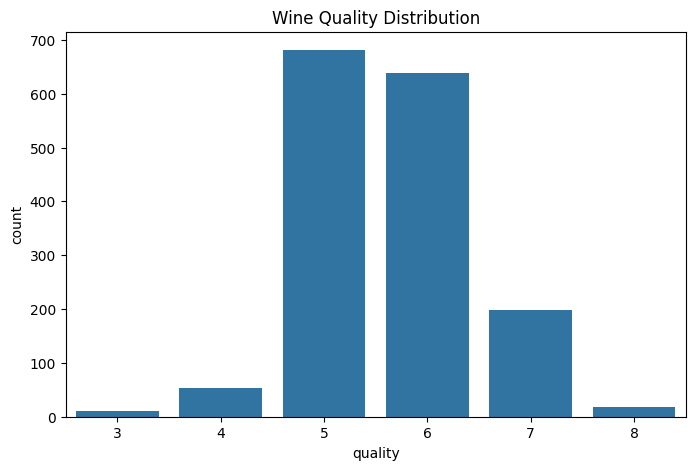

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,x='quality')

plt.title("Wine Quality Distribution")

plt.show()

Observation
* Most wines belong to quality 5 and 6.
* Very few samples have quality 3, 4, 7, or 8.
* Dataset is imbalanced.

Distribution of All Features

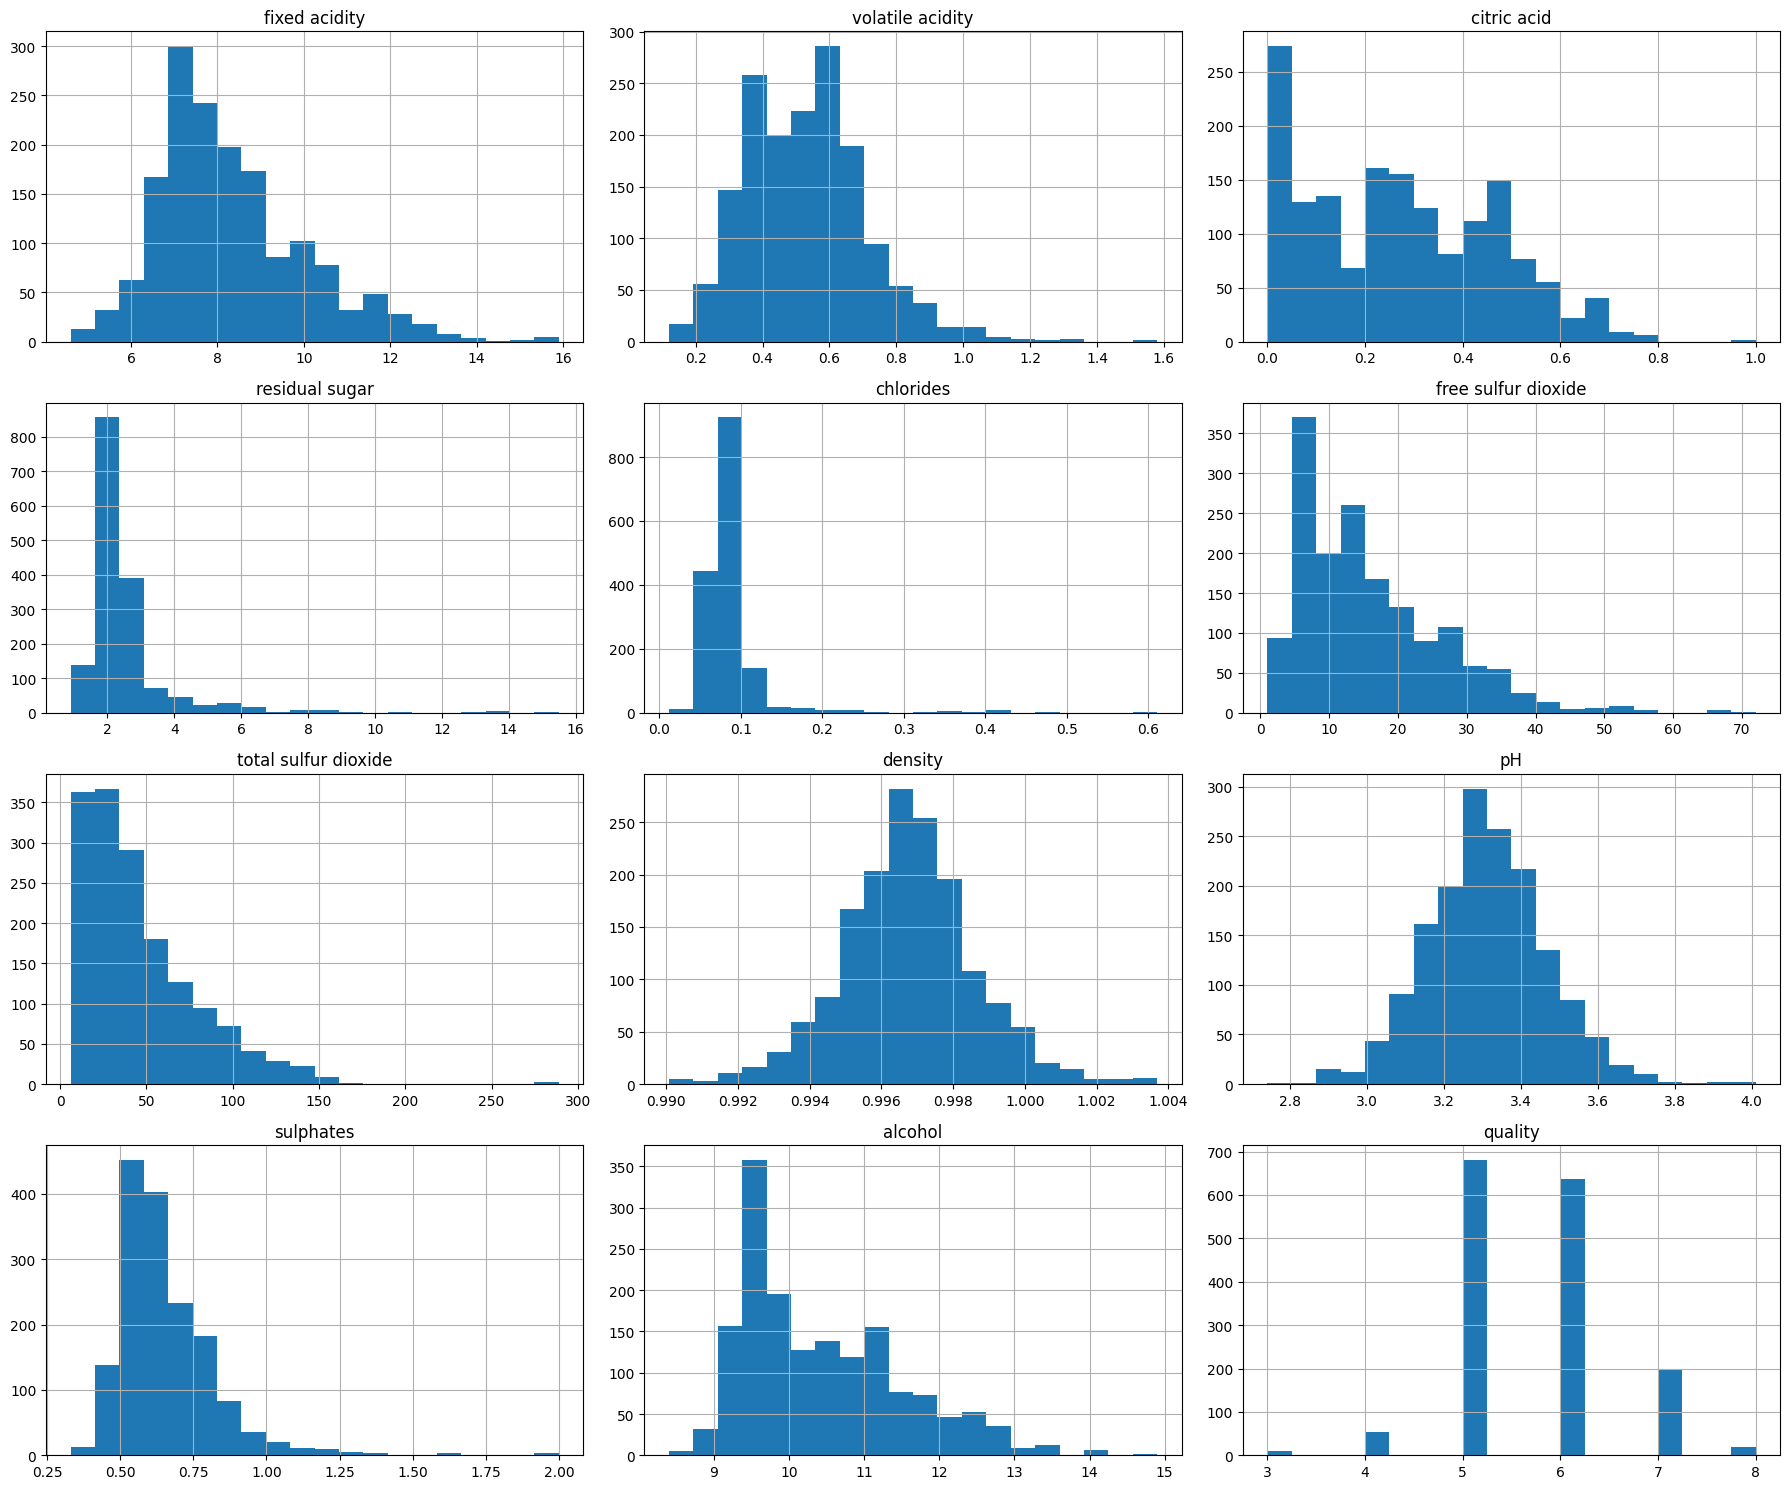

In [10]:
df.hist(figsize=(18,15),bins=20)

plt.tight_layout()

plt.show()

Correlation Heatmap

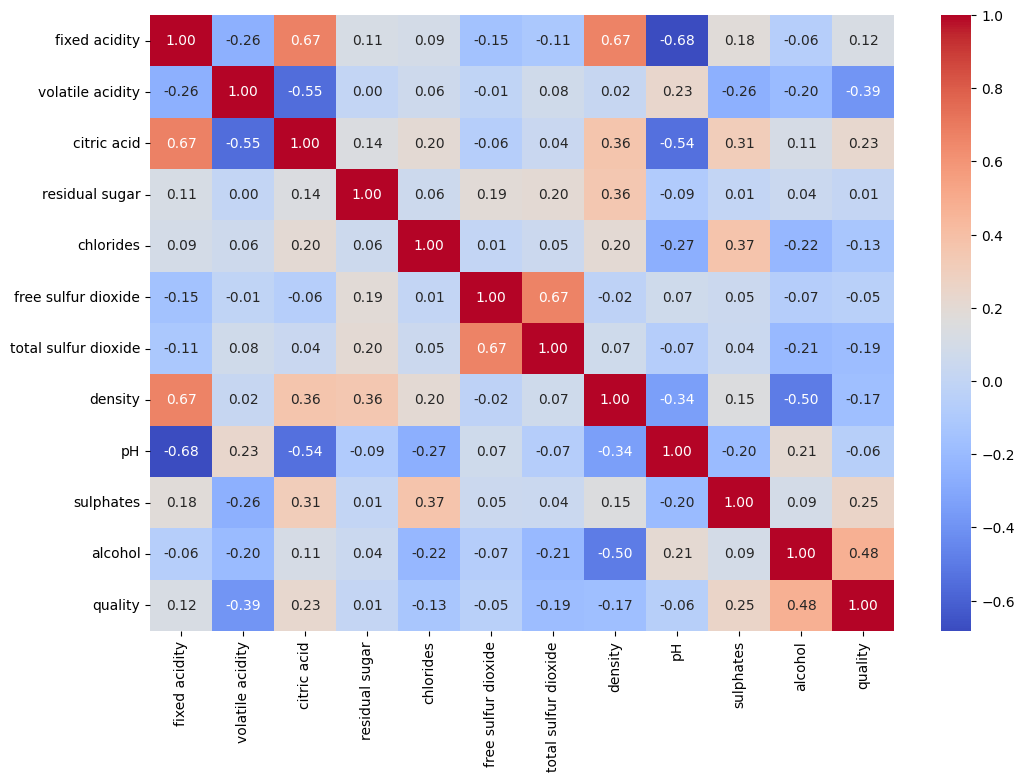

In [11]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.show()

Discuss Class Imbalance:

The dataset is imbalanced because quality scores 5 and 6 dominate the dataset while qualities 3, 4, 7, and 8 have relatively few samples. Models trained on imbalanced data tend to predict the majority classes more often, resulting in lower performance for minority quality levels.

Feature Engineering

Convert quality into Good/Bad

In [12]:
df['quality']=df['quality'].apply(lambda x:1 if x>=7 else 0)

df['quality'].value_counts()


#Good = 1
#Bad = 0 

quality
0    1382
1     217
Name: count, dtype: int64

Split DataSet

In [13]:
X=df.drop('quality',axis=1)

y=df['quality']

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Feature Scaling

In [14]:
scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)

X_test=scaler.transform(X_test)

Random Forest

In [15]:
rf=RandomForestClassifier(random_state=42)

rf.fit(X_train,y_train)

rf_pred=rf.predict(X_test)

print("Accuracy:",accuracy_score(y_test,rf_pred))

print(classification_report(y_test,rf_pred))

Accuracy: 0.9375
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       277
           1       0.93      0.58      0.71        43

    accuracy                           0.94       320
   macro avg       0.93      0.79      0.84       320
weighted avg       0.94      0.94      0.93       320



Confusion Matrix


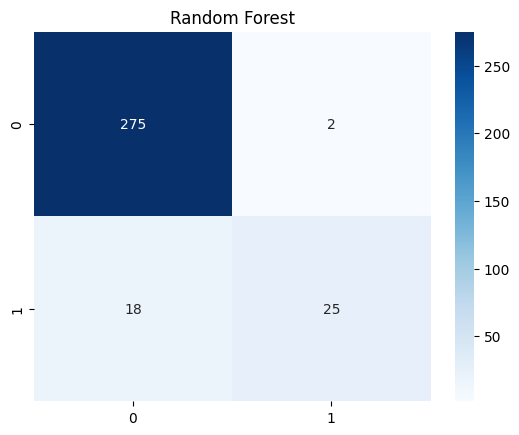

In [16]:
cm=confusion_matrix(y_test,rf_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Random Forest")

plt.show()

SGD Classifier

In [17]:
sgd=SGDClassifier(random_state=42)

sgd.fit(X_train,y_train)

sgd_pred=sgd.predict(X_test)

print(accuracy_score(y_test,sgd_pred))

print(classification_report(y_test,sgd_pred))

0.86875
              precision    recall  f1-score   support

           0       0.92      0.93      0.92       277
           1       0.51      0.47      0.49        43

    accuracy                           0.87       320
   macro avg       0.72      0.70      0.71       320
weighted avg       0.86      0.87      0.87       320



Confusion Matrix

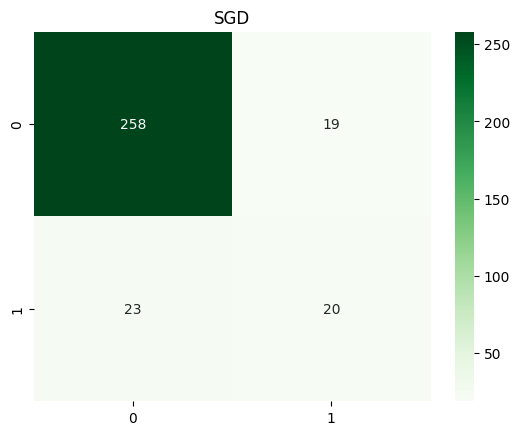

In [18]:
cm=confusion_matrix(y_test,sgd_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Greens')

plt.title("SGD")

plt.show()

In [19]:
#Suppose Vector Classfier
svc=SVC(random_state=42)

svc.fit(X_train,y_train)

svc_pred=svc.predict(X_test)

print(accuracy_score(y_test,svc_pred))

print(classification_report(y_test,svc_pred))

0.9
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       277
           1       0.76      0.37      0.50        43

    accuracy                           0.90       320
   macro avg       0.84      0.68      0.72       320
weighted avg       0.89      0.90      0.88       320



confusion Matrix

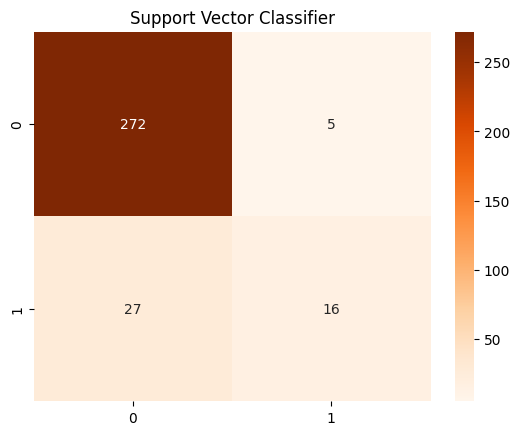

In [20]:
cm=confusion_matrix(y_test,svc_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Oranges')

plt.title("Support Vector Classifier")

plt.show()

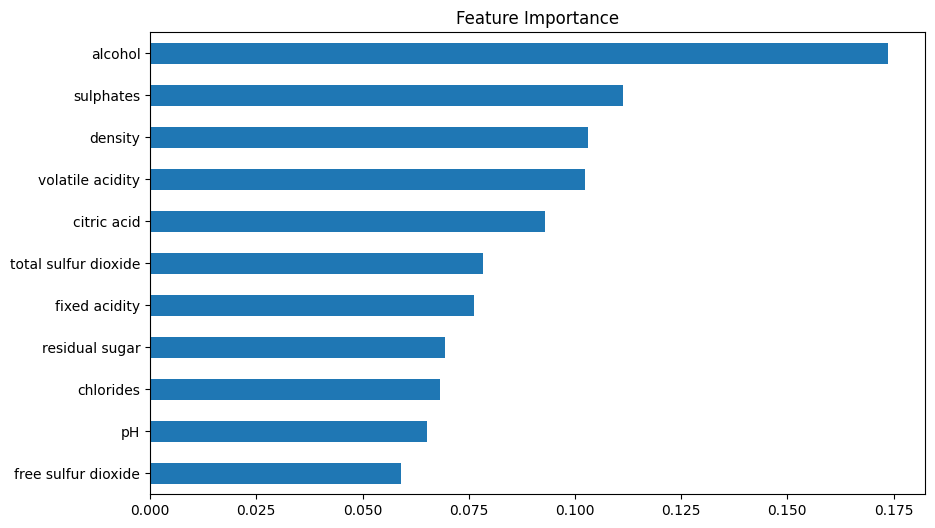

In [21]:
# Feature Importance
importance=pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title("Feature Importance")

plt.show()

In [22]:
#Model Comparision
comparison=pd.DataFrame({

'Model':['Random Forest',
         'SGD',
         'SVC'],

'Accuracy':[

accuracy_score(y_test,rf_pred),

accuracy_score(y_test,sgd_pred),

accuracy_score(y_test,svc_pred)

]

})

comparison

,Model,Accuracy
0,Random Forest,0.93750
1,SGD,0.86875
2,SVC,0.90000


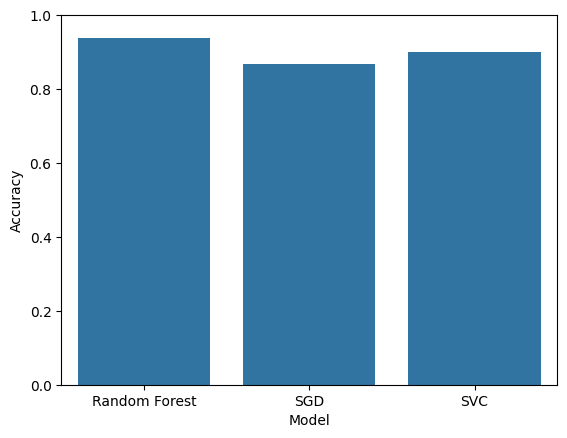

In [23]:

#Best Model
sns.barplot(
    data=comparison,
    x='Model',
    y='Accuracy'
)

plt.ylim(0,1)

plt.show()

Conclusion

• The Wine Quality dataset showed class imbalance, with quality scores 5 and 6 dominating.

• Converting the target into a binary classification problem (Good vs Bad) simplified modelling and improved class separation.

• Random Forest achieved the highest accuracy and provided feature importance scores, making it both accurate and interpretable.

• SGD Classifier trained quickly but generally produced lower accuracy.

• Support Vector Classifier performed competitively but required feature scaling and had higher computational cost.

• Random Forest is the most suitable model for deployment because it offers strong predictive performance, robustness to noisy features, and clear feature importance for interpretation.